# Estimación del ATE: Efecto de Asistir a Clase

**Pregunta causal:** ¿Cuál es el efecto causal (ATE) de asistir a clases (tratamiento) sobre la aprobación de los exámenes y la materia?

- **Tratamiento (A):** Alta asistencia (% de asistencia ≥ umbral)
- **Outcomes (Y):** `apr1`, `apr2`, `apr3`, `apr4`, `aprGlob` (1 = Aprobó, 0 = No aprobó)
- **Covariables:** Variables sociodemográficas y de perfil académico

## 1. Librerías

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import causalidad as cs

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Carga y merge de los datos

In [22]:
# Rutas de los archivos
PATH_ASIST = r"C:\Users\afpue\OneDrive\Documentos\GitHub\causalidad\grupoEstadistica\asistencia.csv"
PATH_BD    = r"C:\Users\afpue\OneDrive\Documentos\GitHub\causalidad\grupoEstadistica\baseDatos2025-2final.xlsx"

# Carga
df_asist = pd.read_csv(PATH_ASIST)
df_bd    = pd.read_excel(PATH_BD)

print(f"Asistencia:    {df_asist.shape[0]} filas, {df_asist.shape[1]} columnas")
print(f"Base de datos: {df_bd.shape[0]} filas, {df_bd.shape[1]} columnas")

Asistencia:    71 filas, 40 columnas
Base de datos: 71 filas, 100 columnas


In [23]:
# ── Limpieza de claves para el merge ────────────────────────────────────────
df_asist['usuario'] = df_asist['Nombre de usuario'].str.strip()
df_bd['usuario']    = df_bd['usuario'].str.strip()

# Verificar solapamiento
asist_users = set(df_asist['usuario'])
bd_users    = set(df_bd['usuario'])
comunes     = asist_users & bd_users
solo_asist  = asist_users - bd_users
solo_bd     = bd_users - asist_users

print(f"Usuarios en asistencia: {len(asist_users)}")
print(f"Usuarios en BD:         {len(bd_users)}")
print(f"En común:               {len(comunes)}")
print(f"Solo en asistencia:     {solo_asist}")
print(f"Solo en BD:             {solo_bd}")

Usuarios en asistencia: 71
Usuarios en BD:         71
En común:               70
Solo en asistencia:     {'afpuertav'}
Solo en BD:             {'sgomezc16'}


In [24]:
# ── Merge por usuario (inner → solo los que están en ambos) ─────────────────
# De asistencia solo nos quedamos con el % de asistencia
asist_slim = df_asist[['usuario', '% de asistencia']].rename(
    columns={'% de asistencia': 'pct_asistencia'}
)

df = pd.merge(df_bd, asist_slim, on='usuario', how='inner')
print(f"Filas tras el merge: {len(df)}")
print(f"Rango de asistencia: {df['pct_asistencia'].min():.1f}% — {df['pct_asistencia'].max():.1f}%")

Filas tras el merge: 70
Rango de asistencia: 18.8% — 100.0%


## 3. Definición del tratamiento

Definimos **alta asistencia** como el umbral del **75 %** (≥ 75 % de sesiones asistidas). 
Esto es el requisito mínimo típico en muchas materias universitarias.
Puedes ajustar `UMBRAL` a otro valor (p. ej. 80) para comparar.

In [25]:
UMBRAL = 80

df['A'] = (df['pct_asistencia'] >= UMBRAL).astype(int)

print(f"Umbral de tratamiento: {UMBRAL}%")
print(f"Tratados   (A=1, alta asistencia): {df['A'].sum()}  ({df['A'].mean()*100:.1f}%)")
print(f"Controles  (A=0, baja asistencia): {(df['A']==0).sum()}  ({(1-df['A'].mean())*100:.1f}%)")
print()
print("Distribución de asistencia:")
print(df['pct_asistencia'].describe())

Umbral de tratamiento: 80%
Tratados   (A=1, alta asistencia): 29  (41.4%)
Controles  (A=0, baja asistencia): 41  (58.6%)

Distribución de asistencia:
count    70.0000
mean     70.2549
std      20.5071
min      18.7500
25%      56.2500
50%      75.0000
75%      84.3800
max     100.0000
Name: pct_asistencia, dtype: float64


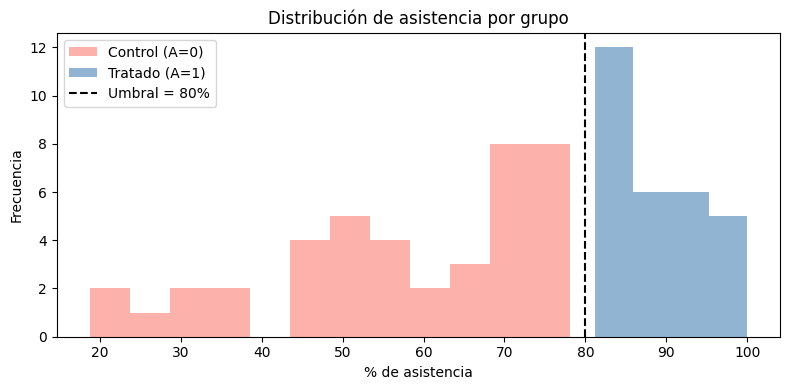

In [26]:
# Histograma de asistencia con el umbral
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[df['A']==0]['pct_asistencia'], bins=12, alpha=0.6, label='Control (A=0)', color='salmon')
ax.hist(df[df['A']==1]['pct_asistencia'], bins=4, alpha=0.6, label='Tratado (A=1)', color='steelblue')
ax.axvline(UMBRAL, color='black', linestyle='--', linewidth=1.5, label=f'Umbral = {UMBRAL}%')
ax.set_xlabel('% de asistencia')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de asistencia por grupo')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Preparación de variables

### 4.1 Outcomes
Convertimos `apr1`–`apr4` y `aprGlob` de «Sí/No» a 0/1.

In [27]:
outcomes = ['apr1', 'apr2', 'apr3', 'apr4', 'aprGlob']

for col in outcomes:
    df[col] = df[col].map({'Sí': 1, 'No': 0, 'Si': 1})

print("Tasa de aprobación por outcome:")
for col in outcomes:
    n_total   = df[col].notna().sum()
    t_apr     = df.loc[df['A']==1, col].mean()
    c_apr     = df.loc[df['A']==0, col].mean()
    naive     = t_apr - c_apr
    print(f"  {col}: tratados={t_apr:.2%}  controles={c_apr:.2%}  naive={naive:+.3%}")

Tasa de aprobación por outcome:
  apr1: tratados=86.21%  controles=78.05%  naive=+8.158%
  apr2: tratados=58.62%  controles=75.61%  naive=-16.989%
  apr3: tratados=37.93%  controles=34.15%  naive=+3.785%
  apr4: tratados=51.72%  controles=51.22%  naive=+0.505%
  aprGlob: tratados=58.62%  controles=63.41%  naive=-4.794%


### 4.2 Covariables

Seleccionamos variables de perfil del estudiante que podrían confundir la relación asistencia → aprobación:

| Variable | Descripción |
|----------|-------------|
| `sex` | Sexo (F/M) |
| `semestre` | Semestre cursado |
| `trabaja` | ¿Trabaja? (0/1) |
| `beca` | ¿Tiene beca? (0/1) |
| `expEstadistica` | Experiencia previa en estadística (0/1) |
| `expPython` | Experiencia en Python (0/1) |
| `caracterCol` | Carácter del colegio (Público/Privado) |
| `actyper01–08` | Actitudes/personalidad (escala Likert → ordinal) |

In [28]:
# ── Codificación de variables ────────────────────────────────────────────────

# Sexo → binario
df['sex_bin'] = (df['sex'] == 'M').astype(int)

# Carácter colegio → binario
df['colegio_privado'] = (df['caracterCol'] == 'Privado').astype(int)

# Carrera → dummies con nombres limpios (sin espacios ni tildes)
carrera_dummies = pd.get_dummies(df['carrera'], prefix='carrera', drop_first=True).astype(int)

# Limpiar nombres: espacios → _, quitar tildes y caracteres especiales
import unicodedata, re

def limpiar_nombre(nombre):
    # Quitar tildes
    nombre = unicodedata.normalize('NFKD', nombre).encode('ascii', 'ignore').decode('ascii')
    # Reemplazar espacios y caracteres no alfanuméricos por _
    nombre = re.sub(r'[^a-zA-Z0-9_]', '_', nombre)
    # Colapsar guiones bajos múltiples
    nombre = re.sub(r'_+', '_', nombre).strip('_')
    return nombre

carrera_dummies.columns = [limpiar_nombre(c) for c in carrera_dummies.columns]
df = pd.concat([df, carrera_dummies], axis=1)
carrera_cols = carrera_dummies.columns.tolist()

# Actitudes Likert → ordinal numérico
likert_map = {
    'Totalmente en desacuerdo': 1,
    'En desacuerdo': 2,
    'Neutral': 3,
    'De acuerdo': 4,
    'Totalmente de acuerdo': 5,
}
actyper_cols = [f'actyper0{i}' for i in range(1, 9)]
actyper_num  = [f'act{i}' for i in range(1, 9)]

for orig, nuevo in zip(actyper_cols, actyper_num):
    df[nuevo] = df[orig].map(likert_map)

# Lista final de covariables
covariables = [
    'sex_bin',
    'semestre',
    'trabaja',
    'rExp',
    'expPython',
    'expMatlab',
    'expOtros',
    'sinExp',
    'beca',
    'expEstadistica',
    'colegio_privado',
]  + carrera_cols + actyper_num

# Eliminar filas con NAs en covariables
df_clean = df[['A', 'pct_asistencia'] + outcomes + covariables].dropna()

print(f"n final (sin NAs): {len(df_clean)}")
print(f"Carreras codificadas: {carrera_cols}")
print(f"Covariables usadas ({len(covariables)}): {covariables}")

n final (sin NAs): 68
Carreras codificadas: ['carrera_Geologia', 'carrera_Ingenieria_Agronomica', 'carrera_Ingenieria_Fisica', 'carrera_Ingenieria_de_Diseno_de_Producto', 'carrera_Ingenieria_de_Sistemas']
Covariables usadas (24): ['sex_bin', 'semestre', 'trabaja', 'rExp', 'expPython', 'expMatlab', 'expOtros', 'sinExp', 'beca', 'expEstadistica', 'colegio_privado', 'carrera_Geologia', 'carrera_Ingenieria_Agronomica', 'carrera_Ingenieria_Fisica', 'carrera_Ingenieria_de_Diseno_de_Producto', 'carrera_Ingenieria_de_Sistemas', 'act1', 'act2', 'act3', 'act4', 'act5', 'act6', 'act7', 'act8']


## 5. Balanceo pre-tratamiento

Revisamos si los grupos tratado y control difieren en las covariables (desbalance).

In [29]:
print("Balance de covariables (antes de ajustar):")
print(f"{'Variable':<20} {'Tratados':>10} {'Controles':>10} {'Diferencia':>12}")
print('─' * 55)
for var in covariables:
    mt = df_clean.loc[df_clean['A']==1, var].mean()
    mc = df_clean.loc[df_clean['A']==0, var].mean()
    print(f"{var:<20} {mt:>10.3f} {mc:>10.3f} {mt-mc:>+12.3f}")

Balance de covariables (antes de ajustar):
Variable               Tratados  Controles   Diferencia
───────────────────────────────────────────────────────
sex_bin                   0.393      0.525       -0.132
semestre                  4.214      4.200       +0.014
trabaja                   0.214      0.200       +0.014
rExp                      0.000      0.000       +0.000
expPython                 0.857      0.725       +0.132
expMatlab                 0.000      0.000       +0.000
expOtros                  0.107      0.100       +0.007
sinExp                    0.036      0.175       -0.139
beca                      0.429      0.475       -0.046
expEstadistica            0.679      0.625       +0.054
colegio_privado           0.643      0.725       -0.082
carrera_Geologia          0.036      0.225       -0.189
carrera_Ingenieria_Agronomica      0.179      0.050       +0.129
carrera_Ingenieria_Fisica      0.107      0.175       -0.068
carrera_Ingenieria_de_Diseno_de_Producto      0

In [30]:
from sklearn.preprocessing import StandardScaler
from numpy.linalg import matrix_rank
import pandas as pd

# ── Diagnóstico de multicolinealidad ─────────────────────────────────────────
X = df_clean[covariables].values
rank = matrix_rank(X)
print(f"Rango de la matriz X: {rank} de {len(covariables)} covariables")
print(f"Columnas con varianza cero: {[v for v in covariables if df_clean[v].std() == 0]}")
print(f"Columnas con >95% mismo valor: {[v for v in covariables if df_clean[v].value_counts(normalize=True).max() > 0.95]}")

# ── Eliminar columnas sin variación o casi constantes ────────────────────────
covariables_filtradas = [
    v for v in covariables
    if df_clean[v].std() > 0                                    # varianza no cero
    and df_clean[v].value_counts(normalize=True).max() < 0.95  # no casi constante
]

print(f"\nCovariables eliminadas: {set(covariables) - set(covariables_filtradas)}")
print(f"Covariables finales ({len(covariables_filtradas)}): {covariables_filtradas}")

# Actualizar covariables
covariables = covariables_filtradas

Rango de la matriz X: 22 de 24 covariables
Columnas con varianza cero: ['rExp', 'expMatlab']
Columnas con >95% mismo valor: ['rExp', 'expMatlab', 'carrera_Ingenieria_de_Diseno_de_Producto']

Covariables eliminadas: {'expMatlab', 'rExp', 'carrera_Ingenieria_de_Diseno_de_Producto'}
Covariables finales (21): ['sex_bin', 'semestre', 'trabaja', 'expPython', 'expOtros', 'sinExp', 'beca', 'expEstadistica', 'colegio_privado', 'carrera_Geologia', 'carrera_Ingenieria_Agronomica', 'carrera_Ingenieria_Fisica', 'carrera_Ingenieria_de_Sistemas', 'act1', 'act2', 'act3', 'act4', 'act5', 'act6', 'act7', 'act8']


## 6. Propensity Score

In [31]:
tratamiento = 'A'

df_ps = cs.propensity_score(df_clean.copy(), tratamiento, covariables)

print()
print(f"PS por grupo:")
print(f"  Tratados  (A=1): media={df_ps.loc[df_ps.A==1,'propensity_score'].mean():.4f}")
print(f"  Controles (A=0): media={df_ps.loc[df_ps.A==0,'propensity_score'].mean():.4f}")

propensity_score() — n=68 (T=28, C=40)
  PS: min=0.0007  p25=0.1469  media=0.4118  p75=0.6391  max=0.9940
  Aviso: 6 unidades (8.8%) con PS < 0.05 o PS > 0.95 — considera trimming o truncating.

PS por grupo:
  Tratados  (A=1): media=0.6003
  Controles (A=0): media=0.2798


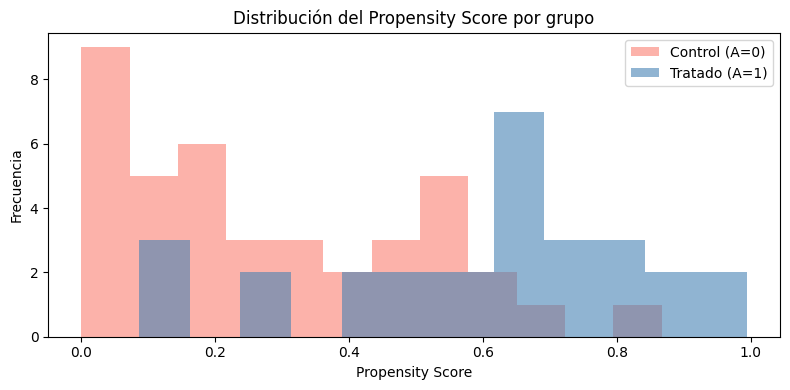

In [32]:
# Histograma de PS por grupo
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_ps.loc[df_ps.A==0,'propensity_score'], bins=12, alpha=0.6, label='Control (A=0)', color='salmon')
ax.hist(df_ps.loc[df_ps.A==1,'propensity_score'], bins=12, alpha=0.6, label='Tratado (A=1)', color='steelblue')
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del Propensity Score por grupo')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Estimación del ATE

Estimamos el ATE para cada outcome (`apr1`, `apr2`, `apr3`, `apr4`, `aprGlob`) 
usando todos los estimadores disponibles en el módulo `causalidad`:

- **naive**: Diferencia de medias simple
- **regresion / g_formula**: Ajuste por regresión OLS
- **ht / hajek**: Ponderación por PS (Horvitz-Thompson / Hájek)
- **msm**: Modelo estructural marginal
- **dr**: Estimador doblemente robusto (recomendado)

Trabajamos sobre el dataset **sin balancear** primero, y luego aplicamos balanceo.

In [33]:
import pandas as pd
from numpy.linalg import matrix_rank

# ── Detectar columnas linealmente dependientes con VIF o rango incremental ───
def eliminar_colineales(df, covs, tol=1e-10):
    """Elimina columnas hasta que la matriz X sea de rango completo."""
    seleccionadas = []
    for col in covs:
        candidatas = seleccionadas + [col]
        X_cand = df[candidatas].dropna().values
        if matrix_rank(X_cand, tol=tol) == len(candidatas):
            seleccionadas.append(col)
        else:
            print(f"  Eliminada por dependencia lineal: {col}")
    return seleccionadas

covariables = eliminar_colineales(df_ps, covariables)
print(f"\nCovariables finales ({len(covariables)}): {covariables}")


Covariables finales (21): ['sex_bin', 'semestre', 'trabaja', 'expPython', 'expOtros', 'sinExp', 'beca', 'expEstadistica', 'colegio_privado', 'carrera_Geologia', 'carrera_Ingenieria_Agronomica', 'carrera_Ingenieria_Fisica', 'carrera_Ingenieria_de_Sistemas', 'act1', 'act2', 'act3', 'act4', 'act5', 'act6', 'act7', 'act8']


In [34]:
estimadores = ['naive', 'regresion', 'g_formula', 'ht', 'hajek', 'msm', 'dr']

# Guardar resultados
resultados = {}

print("=" * 70)
print("ATE SIN BALANCEAR")
print("=" * 70)

for outcome in outcomes:
    df_out = df_ps.dropna(subset=[outcome]).copy()
    res = cs.calcular_ate(df_out, outcome, tratamiento, covariables)
    resultados[outcome] = res
    
    print(f"\n── {outcome} ── (n={len(df_out)}, tratados={df_out['A'].sum()}, controles={(df_out['A']==0).sum()})")
    print(f"  {'Estimador':<14} {'ATE':>8}")
    print(f"  {'─'*24}")
    for key in estimadores:
        val = res[key]
        print(f"  {key:<14} {val:>8.4f}")

ATE SIN BALANCEAR

── apr1 ── (n=68, tratados=28, controles=40)
  Estimador           ATE
  ────────────────────────
  naive            0.1179
  regresion        0.1225
  g_formula        0.1553
  ht               0.2456
  hajek            0.2134
  msm              0.2134
  dr               0.1959


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr2 ── (n=68, tratados=28, controles=40)
  Estimador           ATE
  ────────────────────────
  naive           -0.1429
  regresion       -0.2404
  g_formula       -0.2090
  ht              -0.1349
  hajek           -0.1670
  msm             -0.1670
  dr              -0.2186

── apr3 ── (n=68, tratados=28, controles=40)
  Estimador           ATE
  ────────────────────────
  naive            0.0429
  regresion        0.0273
  g_formula       -0.0384
  ht               0.0095
  hajek           -0.0088
  msm             -0.0088
  dr              -0.0111


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr4 ── (n=68, tratados=28, controles=40)
  Estimador           ATE
  ────────────────────────
  naive            0.0107
  regresion        0.0413
  g_formula       -0.0068
  ht               0.0577
  hajek            0.0333
  msm              0.0333
  dr               0.0094

── aprGlob ── (n=68, tratados=28, controles=40)
  Estimador           ATE
  ────────────────────────
  naive           -0.0429
  regresion       -0.1013
  g_formula       -0.0897
  ht              -0.0615
  hajek           -0.0911
  msm             -0.0911
  dr              -0.1270


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 8. ATE con Balanceo

Dado el tamaño pequeño de muestra (n ≈ 70), aplicamos los métodos de balanceo 
más conservadores. Usamos **trimming**, **truncating** y **matching**.

> **Nota:** Con n tan pequeño, el matching puede dejar muy pocos pares. 
> Si algún outcome queda sin suficientes observaciones, ese estimador puede no converger.

In [35]:
# ── Trimming ─────────────────────────────────────────────────────────────────
df_trim = cs.balance(df_ps, tratamiento, metodo='trimming', kappa=0.05)

print("=" * 70)
print(f"ATE CON TRIMMING (kappa=0.05) — n={len(df_trim)}")
print("=" * 70)

resultados_trim = {}
for outcome in outcomes:
    df_out = df_trim.dropna(subset=[outcome]).copy()
    if len(df_out) < 10:
        print(f"\n── {outcome}: insuficientes datos tras trimming, se omite.")
        continue
    res = cs.calcular_ate(df_out, outcome, tratamiento, covariables)
    resultados_trim[outcome] = res
    
    print(f"\n── {outcome} ── (n={len(df_out)})")
    print(f"  {'Estimador':<14} {'ATE':>8}")
    print(f"  {'─'*24}")
    for key in estimadores:
        val = res[key]
        print(f"  {key:<14} {val:>8.4f}")


──────────────────────────────────────────────────
  balance() | metodo='trimming' | n=68 (T=28, C=40)
──────────────────────────────────────────────────
Trimming (kappa=0.05) — 6 unidades eliminadas (8.8%)  -> n final=62  (tratados=27, controles=35)
  Rango PS conservado: [0.0506, 0.9320]
──────────────────────────────────────────────────

ATE CON TRIMMING (kappa=0.05) — n=62


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr1 ── (n=62)
  Estimador           ATE
  ────────────────────────
  naive            0.1175
  regresion        0.1147
  g_formula        0.1597
  ht               0.3184
  hajek            0.2186
  msm              0.2186
  dr               0.2054


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr2 ── (n=62)
  Estimador           ATE
  ────────────────────────
  naive           -0.1418
  regresion       -0.2259
  g_formula       -0.1842
  ht              -0.0983
  hajek           -0.1739
  msm             -0.1739
  dr              -0.1964


...


── apr3 ── (n=62)
  Estimador           ATE
  ────────────────────────
  naive            0.0931
  regresion        0.0005
  g_formula       -0.0532
  ht               0.0596
  hajek            0.0113
  msm              0.0113
  dr               0.0179


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr4 ── (n=62)
  Estimador           ATE
  ────────────────────────
  naive            0.0698
  regresion        0.0413
  g_formula       -0.0029
  ht               0.1290
  hajek            0.0615
  msm              0.0615
  dr               0.0172


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── aprGlob ── (n=62)
  Estimador           ATE
  ────────────────────────
  naive            0.0011
  regresion       -0.1063
  g_formula       -0.0668
  ht              -0.0016
  hajek           -0.0750
  msm             -0.0750
  dr              -0.1092


In [36]:
# ── Truncating ───────────────────────────────────────────────────────────────
df_trunc = cs.balance(df_ps, tratamiento, metodo='truncating', kappa=0.05)

print("=" * 70)
print(f"ATE CON TRUNCATING (kappa=0.05) — n={len(df_trunc)}")
print("=" * 70)

resultados_trunc = {}
for outcome in outcomes:
    df_out = df_trunc.dropna(subset=[outcome]).copy()
    if len(df_out) < 10:
        print(f"\n── {outcome}: insuficientes datos, se omite.")
        continue
    res = cs.calcular_ate(df_out, outcome, tratamiento, covariables)
    resultados_trunc[outcome] = res
    
    print(f"\n── {outcome} ── (n={len(df_out)})")
    print(f"  {'Estimador':<14} {'ATE':>8}")
    print(f"  {'─'*24}")
    for key in estimadores:
        val = res[key]
        print(f"  {key:<14} {val:>8.4f}")


──────────────────────────────────────────────────
  balance() | metodo='truncating' | n=68 (T=28, C=40)
──────────────────────────────────────────────────
Truncating (kappa=0.05) — 6 PS truncados (8.8%)  -> n=68 (sin eliminar filas)
  PS original:  [0.0007, 0.9940]  ->  PS truncado: [0.0500, 0.9500]
──────────────────────────────────────────────────

ATE CON TRUNCATING (kappa=0.05) — n=68


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr1 ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive            0.1179
  regresion        0.1225
  g_formula        0.1553
  ht               0.2439
  hajek            0.2129
  msm              0.2129
  dr               0.1958

── apr2 ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive           -0.1429
  regresion       -0.2404
  g_formula       -0.2090
  ht              -0.1361
  hajek           -0.1665
  msm             -0.1665
  dr              -0.2188

── apr3 ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive            0.0429
  regresion        0.0273
  g_formula       -0.0384
  ht               0.0079
  hajek           -0.0095
  msm             -0.0095
  dr              -0.0118


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr4 ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive            0.0107
  regresion        0.0413
  g_formula       -0.0068
  ht               0.0557
  hajek            0.0324
  msm              0.0324
  dr               0.0092

── aprGlob ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive           -0.0429
  regresion       -0.1013
  g_formula       -0.0897
  ht              -0.0634
  hajek           -0.0915
  msm             -0.0915
  dr              -0.1274


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [37]:
# ── Matching ─────────────────────────────────────────────────────────────────
df_match = cs.balance(df_ps, tratamiento, metodo='matching')

print("=" * 70)
print(f"ATE CON MATCHING — n={len(df_match)} ({len(df_match)//2} pares)")
print("=" * 70)

resultados_match = {}
for outcome in outcomes:
    df_out = df_match.dropna(subset=[outcome]).copy()
    if df_out['A'].sum() < 5 or (df_out['A']==0).sum() < 5:
        print(f"\n── {outcome}: pocos datos tras matching, se omite.")
        continue
    res = cs.calcular_ate(df_out, outcome, tratamiento, covariables)
    resultados_match[outcome] = res
    
    print(f"\n── {outcome} ── (n={len(df_out)})")
    print(f"  {'Estimador':<14} {'ATE':>8}")
    print(f"  {'─'*24}")
    for key in estimadores:
        val = res[key]
        print(f"  {key:<14} {val:>8.4f}")


──────────────────────────────────────────────────
  balance() | metodo='matching' | n=68 (T=28, C=40)
──────────────────────────────────────────────────
Matching 1:1 — 28 pares  (tratados=28, controles=28)
──────────────────────────────────────────────────

ATE CON MATCHING — n=56 (28 pares)


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr1 ── (n=56)
  Estimador           ATE
  ────────────────────────
  naive            0.0714
  regresion        0.0831
  g_formula        0.0657
  ht               0.4483
  hajek            0.1981
  msm              0.1981
  dr               0.1834

── apr2 ── (n=56)
  Estimador           ATE
  ────────────────────────
  naive           -0.2143
  regresion       -0.2270
  g_formula       -0.2648
  ht              -0.0296
  hajek           -0.2176
  msm             -0.2176
  dr              -0.2789

── apr3 ── (n=56)
  Estimador           ATE
  ────────────────────────
  naive            0.0357
  regresion       -0.0004
  g_formula       -0.0566
  ht               0.0852
  hajek           -0.0360
  msm             -0.0360
  dr              -0.0081


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr4 ── (n=56)
  Estimador           ATE
  ────────────────────────
  naive            0.0714
  regresion        0.0531
  g_formula       -0.0358
  ht               0.2203
  hajek            0.0543
  msm              0.0543
  dr               0.0181

── aprGlob ── (n=56)
  Estimador           ATE
  ────────────────────────
  naive           -0.0714
  regresion       -0.1102
  g_formula       -0.1053
  ht               0.0570
  hajek           -0.1260
  msm             -0.1260
  dr              -0.1582


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 9. Resumen comparativo (estimador DR)

El estimador **doblemente robusto (DR)** es el más confiable cuando el PS 
o el modelo de outcome puede estar mal especificado. Lo usamos como referencia.

In [38]:
print(f"{'Outcome':<12} {'Sin bal.':>10} {'Trimming':>10} {'Truncating':>12} {'Matching':>10}")
print('─' * 58)

for outcome in outcomes:
    v_orig  = resultados.get(outcome, {}).get('dr', float('nan'))
    v_trim  = resultados_trim.get(outcome, {}).get('dr', float('nan'))
    v_trunc = resultados_trunc.get(outcome, {}).get('dr', float('nan'))
    v_match = resultados_match.get(outcome, {}).get('dr', float('nan'))
    print(f"{outcome:<12} {v_orig:>10.4f} {v_trim:>10.4f} {v_trunc:>12.4f} {v_match:>10.4f}")

print()
print("Interpretación: ATE > 0 → asistir aumenta la probabilidad de aprobar.")

Outcome        Sin bal.   Trimming   Truncating   Matching
──────────────────────────────────────────────────────────
apr1             0.1959     0.2054       0.1958     0.1834
apr2            -0.2186    -0.1964      -0.2188    -0.2789
apr3            -0.0111     0.0179      -0.0118    -0.0081
apr4             0.0094     0.0172       0.0092     0.0181
aprGlob         -0.1270    -0.1092      -0.1274    -0.1582

Interpretación: ATE > 0 → asistir aumenta la probabilidad de aprobar.


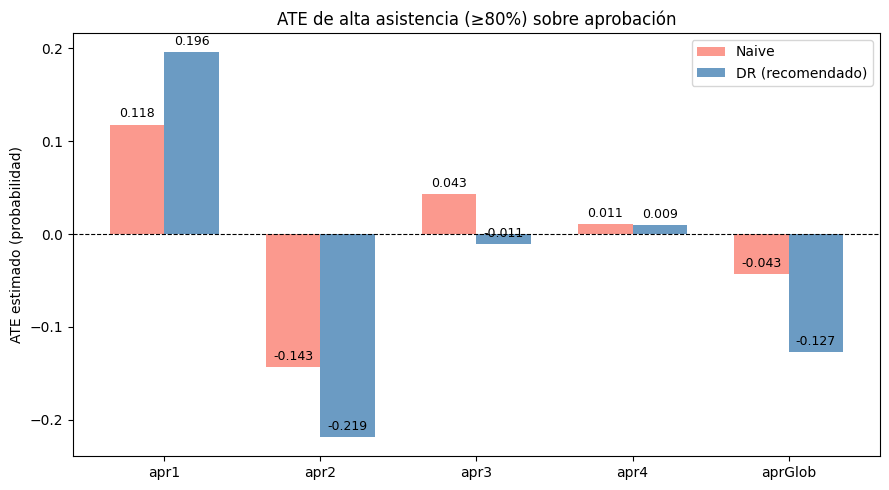

In [39]:
# Gráfica resumen del ATE (DR) sin balancear
ate_dr   = [resultados[o]['dr'] for o in outcomes if o in resultados]
ate_naive = [resultados[o]['naive'] for o in outcomes if o in resultados]

x = np.arange(len(outcomes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, ate_naive, width, label='Naive', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, ate_dr,    width, label='DR (recomendado)', color='steelblue', alpha=0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(outcomes)
ax.set_ylabel('ATE estimado (probabilidad)')
ax.set_title(f'ATE de alta asistencia (≥{UMBRAL}%) sobre aprobación')
ax.legend()

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Subclasificación

In [40]:
# Con n ≈ 70 usamos pocas subclases para no vaciar subgrupos
df_sub = cs.balance(df_ps, tratamiento, metodo='subclassif', n_subclases=3)

print("Distribución por subclase:")
for sc in sorted(df_sub['subclase'].dropna().unique()):
    sub = df_sub[df_sub['subclase'] == sc]
    nt  = (sub[tratamiento] == 1).sum()
    nc  = (sub[tratamiento] == 0).sum()
    print(f"  Subclase {int(sc)}: n={len(sub):3d}  T={nt:3d}  C={nc:3d}  "
          f"PS_medio={sub['propensity_score'].mean():.3f}")

print()
print("=" * 70)
print(f"ATE CON SUBCLASIFICACIÓN (3 subclases)")
print("=" * 70)

resultados_sub = {}
for outcome in outcomes:
    df_out = df_sub.dropna(subset=[outcome]).copy()
    if len(df_out) < 10:
        print(f"\n── {outcome}: insuficientes datos, se omite.")
        continue
    res = cs.calcular_ate(df_out, outcome, tratamiento, covariables)
    resultados_sub[outcome] = res
    
    print(f"\n── {outcome} ── (n={len(df_out)})")
    print(f"  {'Estimador':<14} {'ATE':>8}")
    print(f"  {'─'*24}")
    for key in estimadores:
        val = res[key]
        print(f"  {key:<14} {val:>8.4f}")


──────────────────────────────────────────────────
  balance() | metodo='subclassif' | n=68 (T=28, C=40)
──────────────────────────────────────────────────
Subclasificación — 3 subclases (solicitadas: 3)
  Subclase  1: n=  23  tratados=  3  controles= 20  PS_medio=0.101
  Subclase  2: n=  22  tratados=  7  controles= 15  PS_medio=0.404
  Subclase  3: n=  23  tratados= 18  controles=  5  PS_medio=0.730
──────────────────────────────────────────────────

Distribución por subclase:
  Subclase 1: n= 23  T=  3  C= 20  PS_medio=0.101
  Subclase 2: n= 22  T=  7  C= 15  PS_medio=0.404
  Subclase 3: n= 23  T= 18  C=  5  PS_medio=0.730

ATE CON SUBCLASIFICACIÓN (3 subclases)

── apr1 ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive            0.1179
  regresion        0.1225
  g_formula        0.1553
  ht               0.2456
  hajek            0.2134
  msm              0.2134
  dr               0.1959


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr2 ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive           -0.1429
  regresion       -0.2404
  g_formula       -0.2090
  ht              -0.1349
  hajek           -0.1670
  msm             -0.1670
  dr              -0.2186

── apr3 ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive            0.0429
  regresion        0.0273
  g_formula       -0.0384
  ht               0.0095
  hajek           -0.0088
  msm             -0.0088
  dr              -0.0111


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── apr4 ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive            0.0107
  regresion        0.0413
  g_formula       -0.0068
  ht               0.0577
  hajek            0.0333
  msm              0.0333
  dr               0.0094

── aprGlob ── (n=68)
  Estimador           ATE
  ────────────────────────
  naive           -0.0429
  regresion       -0.1013
  g_formula       -0.0897
  ht              -0.0615
  hajek           -0.0911
  msm             -0.0911
  dr              -0.1270


c:\Users\afpue\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 11. Notas metodológicas

1. **Tamaño de muestra pequeño (n ≈ 70):** Los estimadores basados en PS son más variables con n pequeño. El estimador DR y regresión son los más estables en este contexto.

2. **Supuesto de ignorabilidad:** Asumimos que, condicional a las covariables seleccionadas, la asistencia es «como si fuera aleatoria». Esto puede no cumplirse si hay variables no observadas (p. ej. motivación intrínseca del estudiante).

3. **Outcomes binarios:** El ATE se interpreta como **diferencia de probabilidades** de aprobación entre el grupo de alta asistencia y el de baja asistencia, ajustada por las covariables.

4. **Umbral de tratamiento:** El umbral del 75% es una decisión arbitraria. Un análisis de sensibilidad variando el umbral (p. ej. 70%, 80%) fortalecería las conclusiones.